# Capstone Milestone 2: EDA Dashboard

This notebook satisfies the M2 EDA requirements using the enhanced panel from M1.

## Research Focus
How does the federal funds rate relate to state unemployment rates over time, and how does that relationship vary across regions?

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 12

# Resolve project paths
PROJECT_ROOT = Path.cwd()
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROJECT_ROOT / 'data' / 'final' / 'analysis_panel_enhanced.csv'
assert DATA_PATH.exists(), f'Missing dataset: {DATA_PATH}'

df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['state', 'date']).reset_index(drop=True)

print(f'Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f"States: {df['state'].nunique()} | Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Loaded dataset: 20,736 rows x 15 columns
States: 48 | Date range: 1990-01-01 to 2025-12-01


## 1. Summary Statistics and Data Quality
We start by validating dimensions, missingness, and central tendencies before plotting relationships.

In [2]:
display(df.head())

summary_stats = df.describe(include='all').T
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).to_frame('missing_pct')

print('Top missing-value columns (%):')
display(missing_pct.head(10))

print('Core variable summary:')
core_vars = ['unemployment_rate', 'federal_funds_rate', 'national_unemployment_rate', 'inflation_cpi', 'treasury_10y_yield']
display(df[core_vars].describe().T)

,date,state,unemployment_rate,federal_funds_rate,national_unemployment_rate,inflation_cpi,recession_indicator,treasury_10y_yield,total_nonfarm_employment,civilian_labor_force,total_private_employment,manufacturing_employment,cpi,year,month
0,1990-01-01,AK,7.2,8.23,5.4,127.5,0.0,NaN,109196.0,125833.0,91045.0,17797.0,127.4,1990,1
1,1990-02-01,AK,7.2,8.24,5.3,128.0,0.0,8.42,109436.0,125710.0,91259.0,17893.0,128.0,1990,2
2,1990-03-01,AK,7.2,8.28,5.2,128.6,0.0,8.59,109640.0,125801.0,91346.0,17868.0,128.7,1990,3
3,1990-04-01,AK,7.2,8.26,5.4,128.9,0.0,NaN,109674.0,125649.0,91297.0,17845.0,128.9,1990,4
4,1990-05-01,AK,7.2,8.18,5.4,129.1,0.0,9.08,109828.0,125893.0,91229.0,17796.0,129.2,1990,5


Top missing-value columns (%):


,missing_pct
total_private_employment,44.444444
civilian_labor_force,44.444444
cpi,44.444444
manufacturing_employment,44.444444
total_nonfarm_employment,44.444444
treasury_10y_yield,35.879630
unemployment_rate,0.231481
national_unemployment_rate,0.231481
inflation_cpi,0.231481
date,0.000000


Core variable summary:


,count,mean,std,min,25%,50%,75%,max
unemployment_rate,20688.0,5.292672,1.975615,1.70,3.900,4.900,6.300,30.500
federal_funds_rate,20736.0,2.879259,2.340535,0.05,0.235,2.620,5.220,8.290
national_unemployment_rate,20688.0,5.677262,1.739736,3.40,4.400,5.400,6.600,14.800
inflation_cpi,20688.0,209.994677,51.466010,127.50,164.400,211.398,242.637,326.031
treasury_10y_yield,13296.0,4.219856,1.952800,0.62,2.580,4.120,5.680,9.080


## 2. Correlation Heatmap (Required Plot 1)

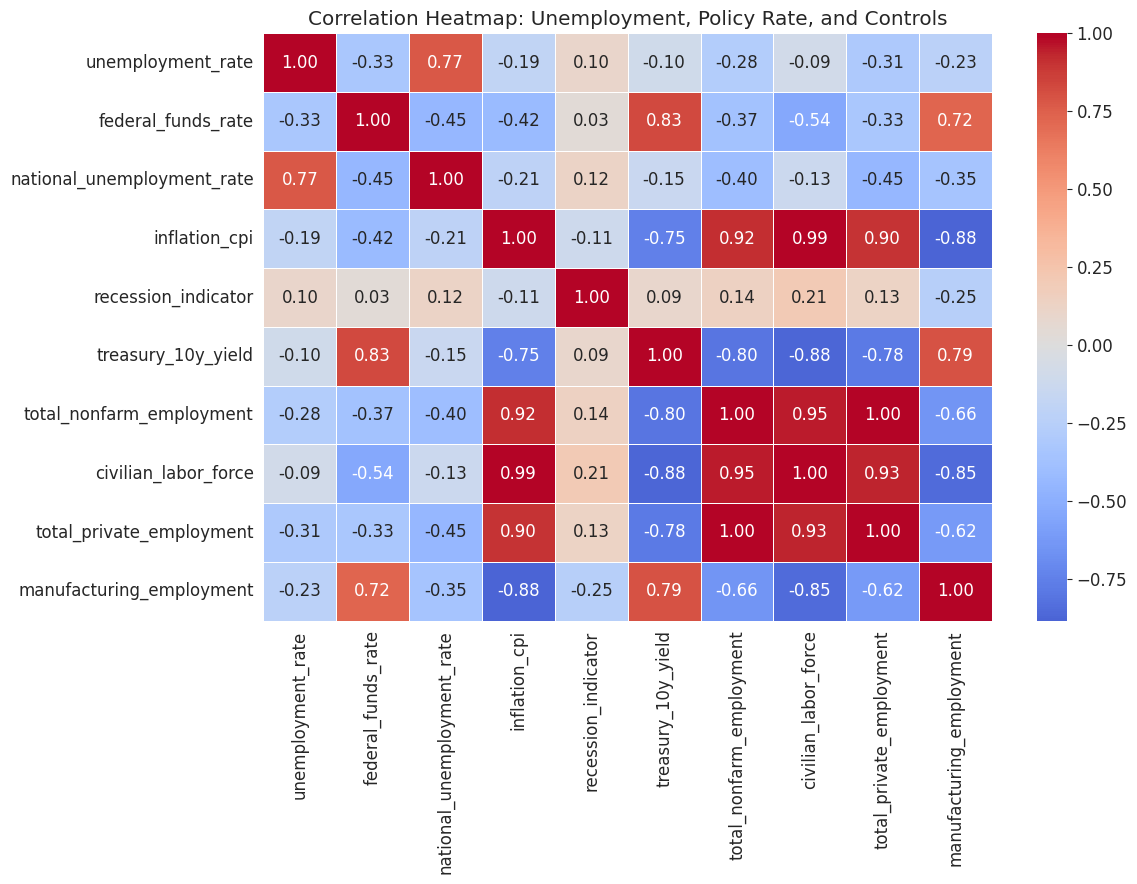

In [3]:
heatmap_vars = [
    'unemployment_rate',
    'federal_funds_rate',
    'national_unemployment_rate',
    'inflation_cpi',
    'recession_indicator',
    'treasury_10y_yield',
    'total_nonfarm_employment',
    'civilian_labor_force',
    'total_private_employment',
    'manufacturing_employment'
]

corr_matrix = df[heatmap_vars].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap: Unemployment, Policy Rate, and Controls')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot1_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** The heatmap shows a moderate negative contemporaneous correlation between unemployment and the federal funds rate, but this should be interpreted as cyclical co-movement and policy endogeneity rather than a causal policy effect. National unemployment remains strongly positively correlated with state unemployment, and the matrix highlights potential control collinearity to manage in M3.

## 3. Time Series of Outcome Variable (Required Plot 2)

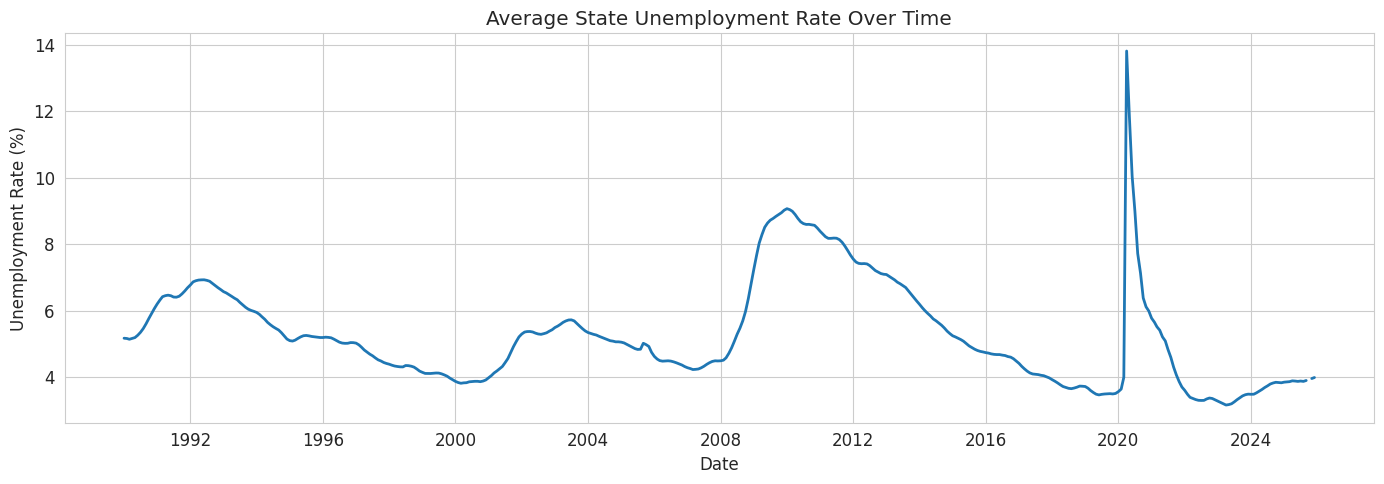

In [4]:
national = df.groupby('date', as_index=False)['unemployment_rate'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(national['date'], national['unemployment_rate'], color='#1f77b4', linewidth=2)
ax.set_title('Average State Unemployment Rate Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot2_outcome_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** Unemployment spikes during major macro shocks (early 1990s, 2008-2009, and 2020), with long recovery periods afterward. This suggests structural breaks and motivates recession controls in M3.

## 4. Dual-Axis Plot: Outcome vs Driver (Required Plot 3)

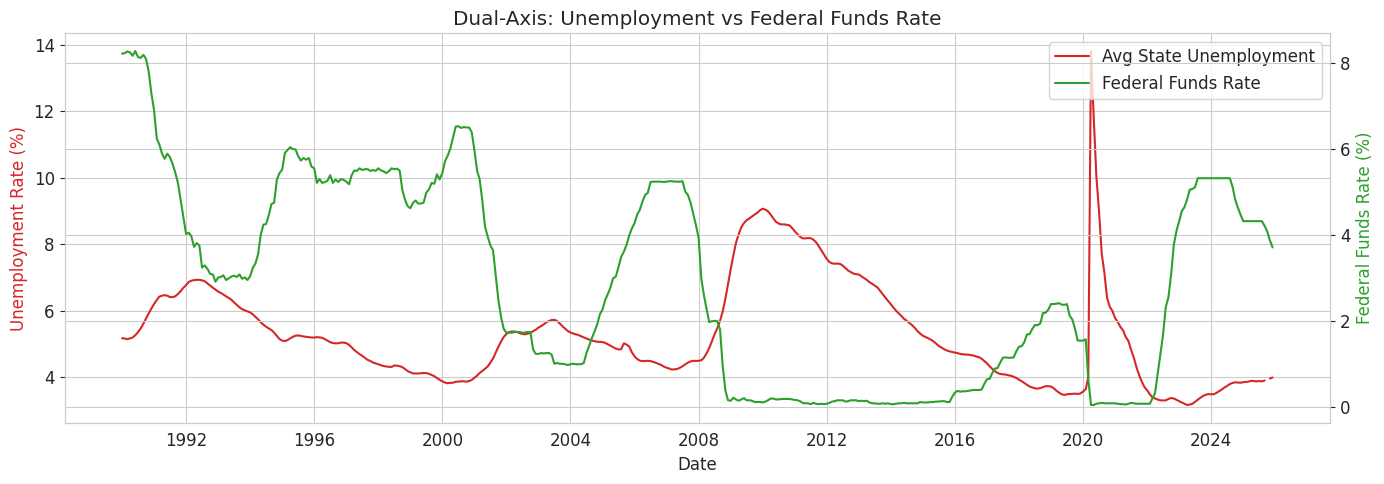

In [5]:
dual = df.groupby('date', as_index=False)[['unemployment_rate', 'federal_funds_rate']].mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

line1 = ax1.plot(dual['date'], dual['unemployment_rate'], color='#d62728', label='Avg State Unemployment')
line2 = ax2.plot(dual['date'], dual['federal_funds_rate'], color='#2ca02c', label='Federal Funds Rate')

ax1.set_title('Dual-Axis: Unemployment vs Federal Funds Rate')
ax1.set_xlabel('Date')
ax1.set_ylabel('Unemployment Rate (%)', color='#d62728')
ax2.set_ylabel('Federal Funds Rate (%)', color='#2ca02c')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot3_dual_axis_unemp_fedfunds.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** The two series often move in opposite directions over long horizons, but this pattern is consistent with business-cycle timing (rates rising in expansions and falling in downturns), not evidence that higher rates mechanically reduce unemployment. Instability around crises suggests regime dependence and motivates dynamic or period-specific specifications in M3.

## 5. Lagged Effect Analysis (Required Plot 4)

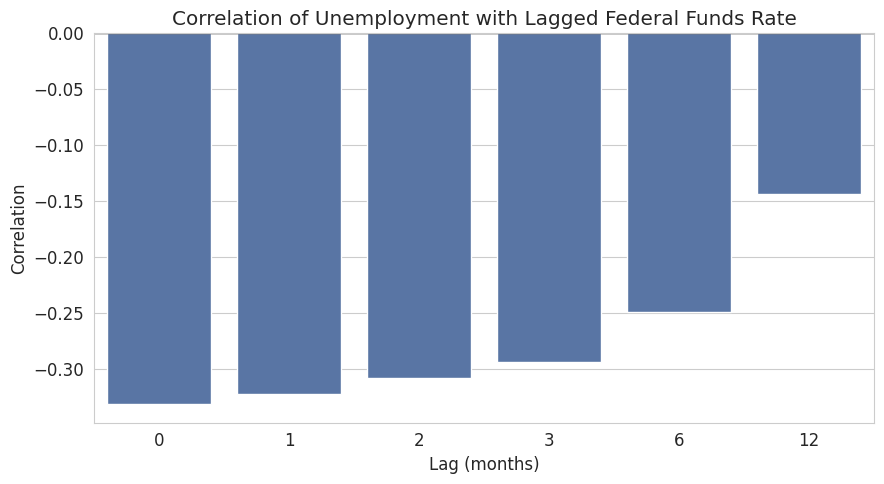

Lag correlations:


,lag_months,correlation
0,0,-0.331555
1,1,-0.322276
2,2,-0.307737
3,3,-0.293498
4,6,-0.248773
5,12,-0.143563


Optimal lag by absolute correlation: 0 month(s)


In [6]:
lags = [0, 1, 2, 3, 6, 12]
lag_corr = []

for lag in lags:
    temp = df.copy()
    temp[f'fed_lag_{lag}'] = temp.groupby('state')['federal_funds_rate'].shift(lag)
    c = temp[['unemployment_rate', f'fed_lag_{lag}']].dropna().corr().iloc[0, 1]
    lag_corr.append({'lag_months': lag, 'correlation': c})

lag_df = pd.DataFrame(lag_corr)
optimal_lag = lag_df.loc[lag_df['correlation'].abs().idxmax(), 'lag_months']

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=lag_df, x='lag_months', y='correlation', color='#4c72b0', ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Correlation of Unemployment with Lagged Federal Funds Rate')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Correlation')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot4_lagged_effects.png', dpi=300, bbox_inches='tight')
plt.show()

print('Lag correlations:')
display(lag_df)
print(f'Optimal lag by absolute correlation: {optimal_lag} month(s)')

**Caption:** The largest absolute correlations appear at short lags (0-1 months) and weaken at longer lags. This supports starting with contemporaneous/near-term reduced-form models, while recognizing that true policy transmission can occur with longer and state-dependent lags that should be tested explicitly in M3.

## 6. Group Box Plots by Region (Required Plot 5)

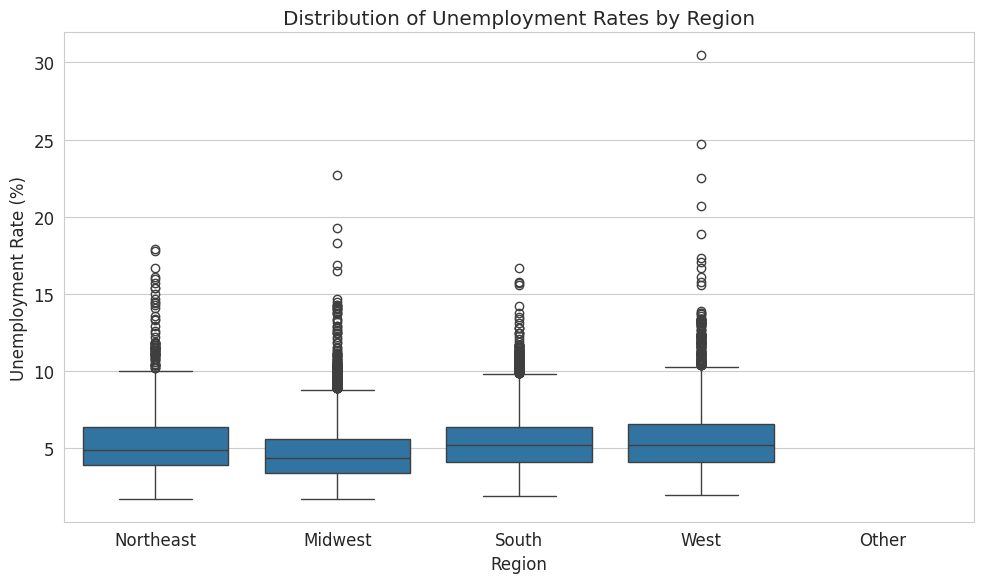

In [7]:
region_map = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast','RI':'Northeast','VT':'Northeast','NJ':'Northeast','NY':'Northeast','PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest','IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest','ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South','SC':'South','VA':'South','DC':'South','WV':'South','AL':'South','KY':'South','MS':'South','TN':'South','AR':'South','LA':'South','OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West','UT':'West','WY':'West','AK':'West','CA':'West','HI':'West','OR':'West','WA':'West'
}

df['region'] = df['state'].map(region_map).fillna('Other')

fig, ax = plt.subplots(figsize=(10, 6))
order = ['Northeast', 'Midwest', 'South', 'West', 'Other']
plot_df = df[df['region'].isin(order)]
sns.boxplot(data=plot_df, x='region', y='unemployment_rate', order=order, ax=ax)
ax.set_title('Distribution of Unemployment Rates by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot5_group_boxplot_region.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** Regional unemployment distributions differ in both median and spread, indicating potential heteroskedasticity and motivating region controls or clustered errors in M3.

## 7. Group Sensitivity to Driver by Region (Required Plot 6)

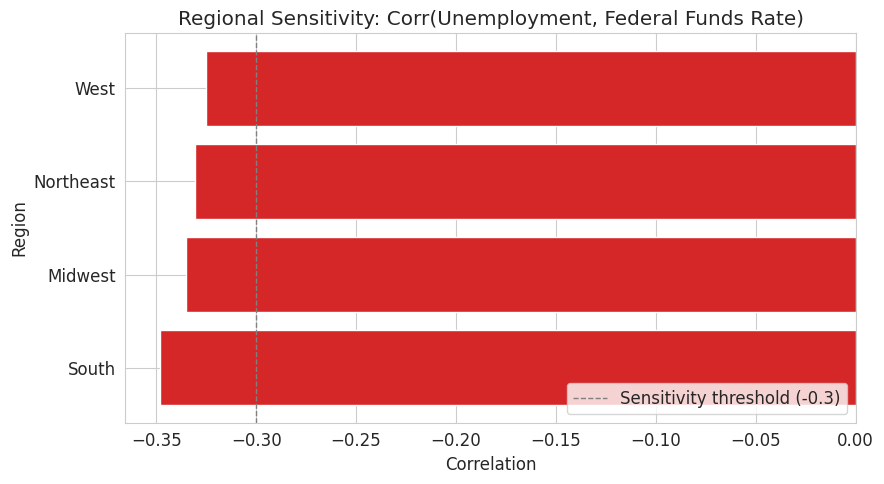

,region,corr_unemp_fedfunds,sensitivity_class
2,South,-0.348073,Sensitive
0,Midwest,-0.335178,Sensitive
1,Northeast,-0.330840,Sensitive
3,West,-0.325111,Sensitive


In [8]:
region_sensitivity = (
    plot_df.groupby('region')
    .apply(lambda x: x['unemployment_rate'].corr(x['federal_funds_rate']))
    .reset_index(name='corr_unemp_fedfunds')
)
region_sensitivity['sensitivity_class'] = np.where(region_sensitivity['corr_unemp_fedfunds'] < -0.3, 'Sensitive', 'Resilient')
region_sensitivity = region_sensitivity.sort_values('corr_unemp_fedfunds')

fig, ax = plt.subplots(figsize=(9, 5))
colors = region_sensitivity['sensitivity_class'].map({'Sensitive':'#d62728', 'Resilient':'#2ca02c'})
ax.barh(region_sensitivity['region'], region_sensitivity['corr_unemp_fedfunds'], color=colors)
ax.axvline(-0.3, color='gray', linestyle='--', linewidth=1, label='Sensitivity threshold (-0.3)')
ax.set_title('Regional Sensitivity: Corr(Unemployment, Federal Funds Rate)')
ax.set_xlabel('Correlation')
ax.set_ylabel('Region')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot6_group_sensitivity_region.png', dpi=300, bbox_inches='tight')
plt.show()

display(region_sensitivity)

**Caption:** Regions differ in reduced-form correlation patterns, suggesting interaction terms between the federal funds rate and region indicators may improve fit. These differences should be interpreted as heterogeneous cyclical exposure and industry composition, not direct evidence of heterogeneous causal policy effects.

## 8. Factor/Control Scatter Plots (Required Plot 7)

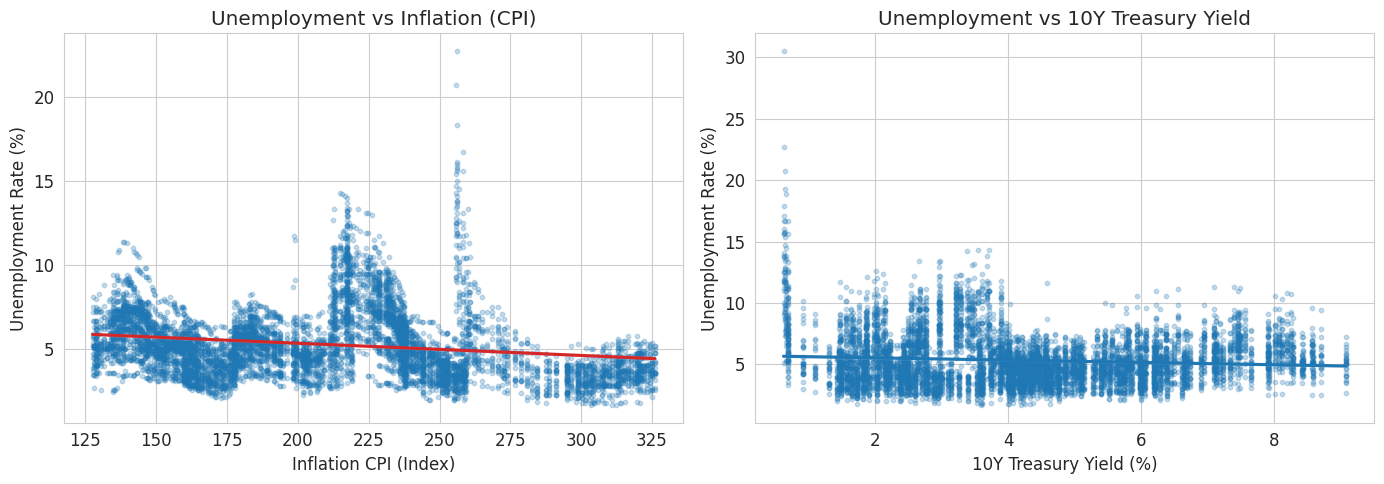

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df.sample(min(8000, len(df)), random_state=42), x='inflation_cpi', y='unemployment_rate',
            scatter_kws={'alpha':0.25, 's':10}, line_kws={'color':'#d62728'}, ax=axes[0])
axes[0].set_title('Unemployment vs Inflation (CPI)')
axes[0].set_xlabel('Inflation CPI (Index)')
axes[0].set_ylabel('Unemployment Rate (%)')

tsy_sample = df.dropna(subset=['treasury_10y_yield']).sample(min(8000, df['treasury_10y_yield'].notna().sum()), random_state=42)
sns.regplot(data=tsy_sample, x='treasury_10y_yield', y='unemployment_rate',
            scatter_kws={'alpha':0.25, 's':10}, line_kws={'color':'#1f77b4'}, ax=axes[1])
axes[1].set_title('Unemployment vs 10Y Treasury Yield')
axes[1].set_xlabel('10Y Treasury Yield (%)')
axes[1].set_ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot7_scatter_controls.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** Control-variable relationships are visible, but signs are regime-dependent in reduced-form data (for example, inflation and yields co-move with growth expectations and policy stance). This supports using them as conditioning variables to reduce omitted-variable bias in M3.

## 9. Time Series Decomposition (Required Plot 8)

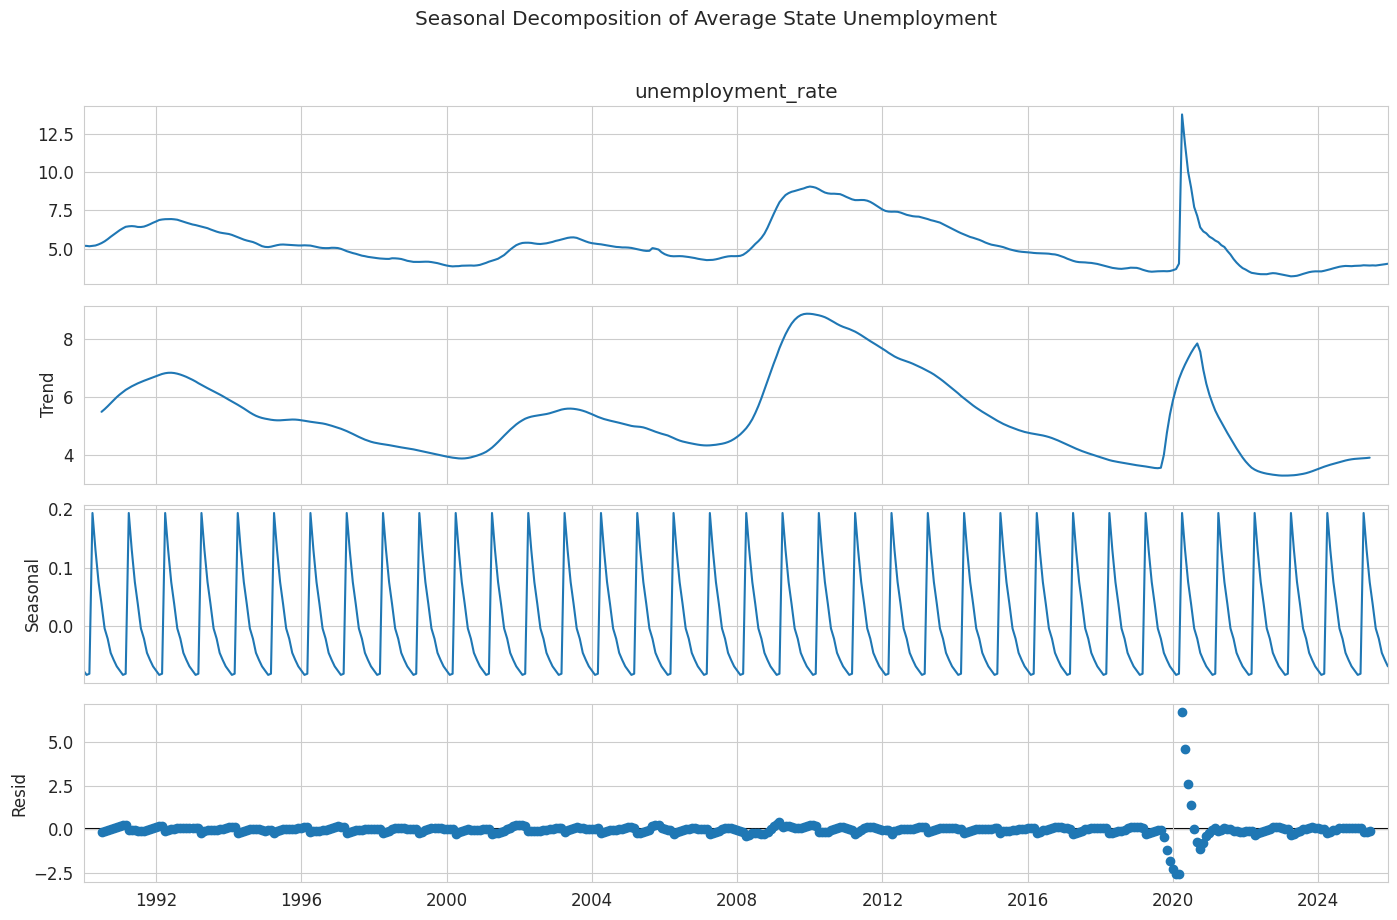

In [10]:
decomp_series = national.set_index('date')['unemployment_rate'].asfreq('MS')
# seasonal_decompose requires no missing values
decomp_series = decomp_series.interpolate(method='time').ffill().bfill()

res = seasonal_decompose(decomp_series, model='additive', period=12)
fig = res.plot()
fig.set_size_inches(14, 9)
fig.suptitle('Seasonal Decomposition of Average State Unemployment', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot8_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

**Caption:** Decomposition separates long-run trend, seasonal pattern, and residual variation. If seasonality is substantial, M3 should include month fixed effects or seasonal controls.

## 10. M3 Hypothesis Drafting Notes
Use findings above to finalize M3 models in M2_EDA_summary.md:
- Main driver hypothesis (reduced form): unemployment and policy rates show negative contemporaneous association due to cyclical co-movement; this is not a causal claim.
- Controls hypothesis: inflation, recession indicator, and macro labor controls improve fit and help absorb business-cycle confounding.
- Heterogeneity hypothesis: reduced-form policy-rate association differs by region because of composition and cyclical exposure differences.
- Specification note: include time fixed effects, recession controls, and lag/lead or dynamic terms when moving from EDA to M3 inference.